Kaggle competition: https://www.kaggle.com/competitions/playground-series-s6e8/overview


In [27]:
import pandas as pd

from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [28]:
from utils.kaggle_mine import download_kaggle_dataset

# download kaggle dataset
download_kaggle_dataset(
    resource="playground-series-s6e8",
    resource_type="competition",
    unzip=True,
    delete_zip=True,
)


Checking destination: /Users/saifullah/Coding/ML/KaggleCompetitions/Predicting Smartphone Addiction/data
Download skipped: destination contains existing data.
Existing files/folders:
  - test.csv
  - train.csv
  - sample_submission.csv


PosixPath('/Users/saifullah/Coding/ML/KaggleCompetitions/Predicting Smartphone Addiction/data')

In [29]:
train_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")
sample_submission = pd.read_csv('./data/sample_submission.csv')

In [30]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Submission columns:", sample_submission.columns.tolist())
print("\nTarget balance:")
print(train_df["addicted_label"].value_counts(normalize=True))


Train shape: (691369, 14)
Test shape: (296302, 13)
Submission columns: ['id', 'addicted_label']

Target balance:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


In [31]:
TARGET = "addicted_label"
ID_COL = "id"

Start training

In [32]:
X = train_df.drop(columns=[TARGET, ID_COL], errors="ignore")
y = train_df[TARGET]


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

In [34]:
numeric_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

categorical_pipeline = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(transformers=[
    (
        "numeric",
        numeric_pipeline,
        selector(dtype_include="number")
    ),
    (
        "categorical",
        categorical_pipeline,
        selector(dtype_include=["object", "category", "bool", "string"])
    )
])

In [35]:
model =  RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

In [36]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

In [37]:
pipeline.fit(
    X_train,y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','daily_screen_time_hours','social_media_hours',...,'gender', 'stress_level','academic_work_impact']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [38]:
# Prediction
y_pred = pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")



Test accuracy: 0.8557
Test accuracy: 85.57%


In [39]:
# Predictions for data the model already learned from
y_train_pred = pipeline.predict(X_train)

training_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training accuracy: {training_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")

Training accuracy: 0.9704
Test accuracy:     0.8557


In [40]:


# 1. Predictions on unseen local test data
y_pred = pipeline.predict(X_test)

# Probability that addicted_label = 1
y_prob = pipeline.predict_proba(X_test)[:, 1]

# 2. Scores
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("MODEL EVALUATION ON X_test")
print("-" * 35)
print(f"Accuracy:  {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

MODEL EVALUATION ON X_test
-----------------------------------
Accuracy:  0.8557  (85.57%)
Precision: 0.9388
Recall:    0.8520
F1 score:  0.8933
ROC-AUC:   0.9401

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78     40179
           1       0.94      0.85      0.89     98095

    accuracy                           0.86    138274
   macro avg       0.82      0.86      0.84    138274
weighted avg       0.87      0.86      0.86    138274



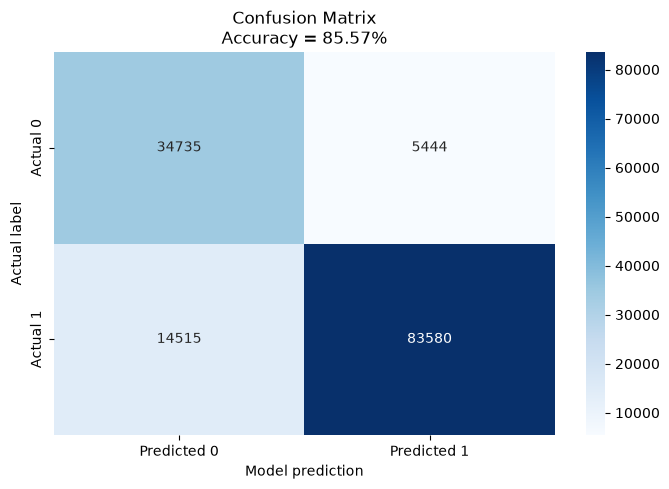

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title(f"Confusion Matrix\nAccuracy = {accuracy:.2%}")
plt.xlabel("Model prediction")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

Full model training

In [42]:
# Train final model using ALL labelled training rows
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','daily_screen_time_hours','social_media_hours',...,'gender', 'stress_level','academic_work_impact']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [43]:
from pathlib import Path
import json
import joblib

# 11. Save the complete fitted pipeline
Path("data/artifacts").mkdir(exist_ok=True)

joblib.dump(
    pipeline,
    "data/artifacts/addiction_pipeline.joblib"
)

# Save expected feature names for the prediction script later
with open("data/artifacts/feature_columns.json", "w") as file:
    json.dump(X.columns.tolist(), file)

print("Model saved: artifacts/addiction_pipeline.joblib")
print("Feature list saved: artifacts/feature_columns.json")


Model saved: artifacts/addiction_pipeline.joblib
Feature list saved: artifacts/feature_columns.json
